<a href="https://colab.research.google.com/github/sonasahakyan11/ecommerce-funnel-analysis/blob/main/User_Behavior_Conversion_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# User Behavior & Conversion Analysis

1. Project Overview

  - Project Goal
  - Key Analyses
  - Tool Used
  - Dataset Description

2. Data Setup
  - Data Loading
  - Import Libraries
  - SQLite DB setup

3. SQL Data Exploration

  - Data Inspection
  - Initial Data Cleaning and Validation
  - Data Quality Check Results
  - Basic Dataset Overview

4. Funnel Analysis

  - Funnel Overview (SQL)
  - Python Behavioral Analysis
    - Funnel Overview (Vertical Format)
    - Funnel Visualization
  - Key Insights & Business Recommendations

5. Segmentation Analysis

  - Funnel Segmentation Analysis by channel (SQL)
  - Marketing Performance Analysis & Visualization — Funnel by Channel (Python, Pandas, Numpy, Matplotlib)
  - Channel Performance Insights & Business Recommendations
  - Funnel Segmentation Analysis by Campaign Type (SQL)
  - Marketing Performance Analysis & Visualization — Funnel by Campaign Type (Python, Pandas, Numpy, Matplotlib)
  - Campaign Type Performance Insights & Business Recommendations

6. Revenue Opportunity Analysis
  - Stage-wise Lost Users Calculation (SQL)
  - Stage-wise Lost Revenue Calculation & Visualisation (Python, Pandas, Matplotlib)
  - Revenue Opportunity Insight

7. Limitations

8. Future Work

9. Appendix – Additional Exploratory Queries

## Project Overview

### Project Goal

The goal of this project is to analyze user behavior across an e-commerce funnel
to identify drop-off points and improve conversion rates.

### Key Analyses:

- SQL-based data exploration
- Funnel conversion analysis
- Segmentation analysis
- Revenue Opportunity Analysis
- Key insights & business recommendations

### Tools used:
- SQL
- Python (Pandas, Numpy)
- Matplotlib

### Dataset Description

The dataset contains user sessions and funnel stage information
for a direct-to-consumer e-commerce platform.



#### **Dataset Structure**

Records: ~120,000 user sessions

Time Period: Approximately 6 months

Granularity: One row per user session

Format: Structured tabular data suitable for relational analysis



#### **Columns:**

Session Identifiers:

- user_id – unique user identifier
- session_id – unique session identifier
Temporal Variables:

- date - date of the session
- month - month of the session

Marketing Attributes:

- channel – Traffic source (Paid Ads, Organic, Social, Email)
- campaign_type – Marketing campaign category (Discount, New Launch, Influencer)

User & Context Variables:

- device – Device type used (Mobile, Desktop)
- user_type – Customer classification (New, Returning)
- region – Geographic classification (Metro, Non-Metro)


Funnel Stage Flags:

- visited_website – Binary indicator for website visit
- viewed_product – Binary indicator for product page view
- added_to_cart – Binary indicator for cart addition
- checkout_started – Binary indicator for checkout initiation
- purchase_completed – Binary indicator for completed purchase

Transaction Metrics:

- order_value – Total value of the order (null if no purchase)
- discount_applied – Discount amount applied to the order
- revenue – Net revenue generated from the session

## Data Setup

### Data Loading - Direct-to-Consumer E-Commerce Funnel Analysis
This notebook demonstrates how to download and load the **Direct-to-Consumer E-Commerce Funnel** dataset from Kaggle using the Kaggle API.
It sets up the environment, downloads the dataset, unzips it, and loads it into a Pandas DataFrame for further analysis.

**Step 1:** Set up Kaggle API

**Step 2:** Download dataset

**Step 3:** Unzip and load CSV

**Step 4:** Explore dataset

In [12]:
# Import os module to set environment variables
# kaggle competitions list
import os
# Set Kaggle API token for authentication
os.environ["KAGGLE_API_TOKEN"] = "KGAT_b48e76fa1be0aa72a321314b94d35f36"
# Install Kaggle package (if not already installed)
!pip install kaggle
# Download the dataset from Kaggle using Kaggle API
!kaggle datasets download -d yashch05/direct-to-consumer-e-commerce-funnel-dataset
!unzip -o direct-to-consumer-e-commerce-funnel-dataset.zip d2c_marketing_funnel_data.csv

import pandas as pd
# Load the CSV dataset into a Pandas DataFrame
df = pd.read_csv("d2c_marketing_funnel_data.csv")
df.head()

Dataset URL: https://www.kaggle.com/datasets/yashch05/direct-to-consumer-e-commerce-funnel-dataset
License(s): unknown
direct-to-consumer-e-commerce-funnel-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  direct-to-consumer-e-commerce-funnel-dataset.zip
  inflating: d2c_marketing_funnel_data.csv  


,user_id,session_id,date,month,channel,campaign_type,device,user_type,region,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed,discount_applied,order_value,revenue
0,221958,1,8/16/2025,2025-08,Organic,New Launch,Mobile,New,Metro,Yes,No,No,No,No,No,499.00,0.000
1,771155,2,12/16/2025,2025-12,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,Yes,No,No,No,499.00,0.000
2,231932,3,7/17/2025,2025-07,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,No,No,No,No,499.00,0.000
3,465838,4,7/4/2025,2025-07,Paid Ads,Discount,Mobile,Returning,Metro,Yes,Yes,Yes,Yes,Yes,Yes,2000.95,1800.855
4,359178,5,8/10/2025,2025-08,Paid Ads,Influencer,Mobile,Returning,Non-Metro,Yes,No,No,No,No,No,499.00,0.000


### Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

### SQLite DB setup

This section demonstrates how to create a SQLite database, load the Direct-to-Consumer E-Commerce Funnel dataset, and run SQL queries for data cleaning and exploration.

In [14]:
# Step 1: Connect to SQLite DB (will create file if does not exist)
conn = sqlite3.connect("ecommerce_funnel.db")
cursor = conn.cursor()

# Step 2: Push CSV into SQLite as a table
df.to_sql("marketing_funnel", conn, if_exists="replace", index=False)

# Check first few rows using SQL
query = "SELECT * FROM marketing_funnel LIMIT 5"
pd.read_sql(query, conn)

,user_id,session_id,date,month,channel,campaign_type,device,user_type,region,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed,discount_applied,order_value,revenue
0,221958,1,8/16/2025,2025-08,Organic,New Launch,Mobile,New,Metro,Yes,No,No,No,No,No,499.00,0.000
1,771155,2,12/16/2025,2025-12,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,Yes,No,No,No,499.00,0.000
2,231932,3,7/17/2025,2025-07,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,No,No,No,No,499.00,0.000
3,465838,4,7/4/2025,2025-07,Paid Ads,Discount,Mobile,Returning,Metro,Yes,Yes,Yes,Yes,Yes,Yes,2000.95,1800.855
4,359178,5,8/10/2025,2025-08,Paid Ads,Influencer,Mobile,Returning,Non-Metro,Yes,No,No,No,No,No,499.00,0.000


## SQL Data Exploration

### Data Inspection

Before cleaning the dataset, we inspect its structure to understand:
- column names and data types
- total number of rows
- a small sample of the dataset


In [15]:
# Inspect table structure (column names and types)
query_table_columns = "PRAGMA table_info(marketing_funnel);"
df_columns = pd.read_sql(query_table_columns, conn)
print(df_columns)

# Check total number of rows
query_table_rows = "SELECT COUNT(*) as total_rows FROM marketing_funnel;"
df_rows = pd.read_sql(query_table_rows, conn)
print(df_rows)

# Preview first 5 rows of the dataset
query_table_sample = "SELECT * FROM marketing_funnel LIMIT 5;"
df_sample = pd.read_sql(query_table_sample, conn)
df_sample


    cid                name     type  notnull dflt_value  pk
0     0             user_id  INTEGER        0       None   0
1     1          session_id  INTEGER        0       None   0
2     2                date     TEXT        0       None   0
3     3               month     TEXT        0       None   0
4     4             channel     TEXT        0       None   0
5     5       campaign_type     TEXT        0       None   0
6     6              device     TEXT        0       None   0
7     7           user_type     TEXT        0       None   0
8     8              region     TEXT        0       None   0
9     9     visited_website     TEXT        0       None   0
10   10      viewed_product     TEXT        0       None   0
11   11       added_to_cart     TEXT        0       None   0
12   12    checkout_started     TEXT        0       None   0
13   13  purchase_completed     TEXT        0       None   0
14   14    discount_applied     TEXT        0       None   0
15   15         order_va

,user_id,session_id,date,month,channel,campaign_type,device,user_type,region,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed,discount_applied,order_value,revenue
0,221958,1,8/16/2025,2025-08,Organic,New Launch,Mobile,New,Metro,Yes,No,No,No,No,No,499.00,0.000
1,771155,2,12/16/2025,2025-12,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,Yes,No,No,No,499.00,0.000
2,231932,3,7/17/2025,2025-07,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,No,No,No,No,499.00,0.000
3,465838,4,7/4/2025,2025-07,Paid Ads,Discount,Mobile,Returning,Metro,Yes,Yes,Yes,Yes,Yes,Yes,2000.95,1800.855
4,359178,5,8/10/2025,2025-08,Paid Ads,Influencer,Mobile,Returning,Non-Metro,Yes,No,No,No,No,No,499.00,0.000


### Initial Data Cleaning and Validation

To ensure the dataset is reliable for analysis, we check for common data quality issues:

- Missing values in key numeric fields (revenue, order_value, discount_applied)
- Duplicate records
- Negative values in revenue or order_value
- Funnel logic violations (invalid user journey steps)

In [16]:
# Check missing values for revenue, order_value, discount_applied
query_for_missing_values = """SELECT
                          SUM(CASE WHEN revenue IS NULL THEN 1 ELSE 0 END) AS missing_revenue,
                          SUM(CASE WHEN order_value IS NULL THEN 1 ELSE 0 END) AS missing_order_value,
                          SUM(CASE WHEN discount_applied IS NULL THEN 1 ELSE 0 END) AS missing_discount_applied
                          FROM marketing_funnel;"""

df_missing_values = pd.read_sql(query_for_missing_values, conn)
print(df_missing_values)

# Check dublicate values
query_for_duplicate_values = """SELECT user_id, session_id,	date, COUNT(*) AS count_dublicates
                                FROM marketing_funnel
                                GROUP BY user_id, session_id,	date
                                HAVING count_dublicates > 1;"""
df_duplicate_values = pd.read_sql(query_for_duplicate_values, conn)
print(df_duplicate_values)

# Check for negative vaues
query_for_negative_revenue_or_order_value = """SELECT *
                                              FROM marketing_funnel
                                              WHERE revenue < 0 OR order_value < 0;"""
df_negative_revenue_or_order_value = pd.read_sql(query_for_negative_revenue_or_order_value, conn)
print(df_negative_revenue_or_order_value)

# Check for funnel inconsistency
query_for_funnel_logic_violation = """SELECT *
                                    FROM marketing_funnel
                                    WHERE (viewed_product = 'Yes' AND visited_website = 'No') OR
                                    (added_to_cart = 'Yes' AND viewed_product = 'No') OR
                                    (checkout_started = 'Yes' AND added_to_cart = 'No') OR
                                    (purchase_completed = 'Yes' AND checkout_started = 'No');"""
df_for_funnel_logic_violation = pd.read_sql(query_for_funnel_logic_violation, conn)
print(df_for_funnel_logic_violation)

   missing_revenue  missing_order_value  missing_discount_applied
0                0                    0                         0
Empty DataFrame
Columns: [user_id, session_id, date, count_dublicates]
Index: []
Empty DataFrame
Columns: [user_id, session_id, date, month, channel, campaign_type, device, user_type, region, visited_website, viewed_product, added_to_cart, checkout_started, purchase_completed, discount_applied, order_value, revenue]
Index: []
Empty DataFrame
Columns: [user_id, session_id, date, month, channel, campaign_type, device, user_type, region, visited_website, viewed_product, added_to_cart, checkout_started, purchase_completed, discount_applied, order_value, revenue]
Index: []


*Note: After inspecting the dataset, no rows with negative revenue or order values were found.
Therefore, validation checks related to negative revenue scenarios were not required.*

### Data Quality Check Results

Several data quality checks were performed to ensure dataset reliability:

- Checked for missing values in key numerical columns (revenue, order_value, discount_applied)
- Checked for duplicate session records
- Checked for negative revenue or order values
- Validated funnel stage logic to ensure sequential consistency․ The query checks for invalid cases where a later funnel stage is completed without completing the previous stage.

The dataset passed all validation checks and was deemed suitable for further analysis.

### Basic Dataset Overview

Key metrics of the marketing funnel dataset:

- **Total sessions:** Total number of user sessions recorded in the dataset.
- **Unique users:** Number of distinct users in the dataset.
- **Total purchases:** Count of sessions where a purchase was completed.
- **Total revenue:** Sum of revenue generated across all sessions.

Provides a high-level understanding of user engagement and overall funnel performance.

In [17]:
# Aggregate basic session and revenue metrics
query_session_numbers = """SELECT COUNT(*) AS total_sessions,
                                  COUNT(DISTINCT user_id) AS unique_users,
                                  SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS total_purchases,
                                  SUM(revenue) AS total_revenue
                           FROM marketing_funnel;"""
df_session_numbers = pd.read_sql(query_session_numbers, conn)
print(df_session_numbers)


   total_sessions  unique_users  total_purchases  total_revenue
0          120000        112352             8181   1.701660e+07


## Funnel Analysis

### Funnel Overview (SQL)

The marketing funnel was summarized to understand user progression through key stages:

- **Total sessions:** Number of sessions in the dataset.
- **Visited website:** Sessions where the website was visited.
- **Viewed product:** Sessions where a product page was viewed.
- **Added to cart:** Sessions where items were added to the cart.
- **Checkout started:** Sessions where checkout was initiated.
- **Purchase completed:** Sessions where a purchase was completed.

Conversion rates between stages were calculated:

- **Visit to View Rate:** Proportion of website visitors who viewed a product.
- **View to Cart Rate:** Proportion of product viewers who added items to the cart.
- **Cart to Checkout Rate:** Proportion of users who started checkout after adding to cart.
- **Checkout to Purchase Rate:** Proportion of users who completed purchase after starting checkout.

These metrics provide insight into funnel efficiency and potential drop-off points.

In [18]:
# Generate funnel overview with conversion rates
query_funnel_overview = """WITH funnel_overview AS (
                                  SELECT
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel)

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_overview;"""
df_funnel_overview = pd.read_sql(query_funnel_overview, conn)
print(df_funnel_overview)

   total_sessions  visited  viewed   cart  checkout  purchase  \
0          120000   120000   77870  27156     16234      8181   

   visit_to_view_rate  view_to_cart_rate  cart_to_checkout_rate  \
0               0.649              0.349                  0.598   

   checkout_to_purchase_rate  
0                      0.504  


> Note: Step-wise conversion rates provide more actionable insight for business decisions than cumulative conversion, as they pinpoint exact stages where drop-offs occur.

### Python Behavioral Analysis

Behavior patterns are examined to identify trends across funnel stages.  
Analysis focuses on session-level engagement, drop-off points, and conversion impact, providing actionable insights for marketing optimization.

#### Funnel Overview (Vertical Format)

The funnel overview has been transformed into a vertical table to facilitate step-wise analysis and visualization.  

- **Stage:** Each row represents a funnel stage, from website visit to purchase completion.  
- **Users:** Number of users who reached each stage.  

This format is optimal for generating bar charts or step-wise conversion visualizations, highlighting drop-off points between stages.

In [19]:
# Convert funnel overview to vertical format
df_funnel_overview_vertical = df_funnel_overview[['visited','viewed','cart','checkout','purchase']].T

# Rename index to 'Stage' (for clarity)
df_funnel_overview_vertical = df_funnel_overview_vertical.rename_axis("Stage")

# Rename column to 'Users'
df_funnel_overview_vertical = df_funnel_overview_vertical.rename(columns={0: "Users"})

print(df_funnel_overview_vertical)

           Users
Stage           
visited   120000
viewed     77870
cart       27156
checkout   16234
purchase    8181


#### Funnel Visualization

A bar chart is created to visualize the number of users at each funnel stage.  
Step-wise conversion rates are overlaid on the bars to highlight drop-off points and stage efficiency.  
This visual representation supports actionable insights for optimizing the e-commerce funnel.


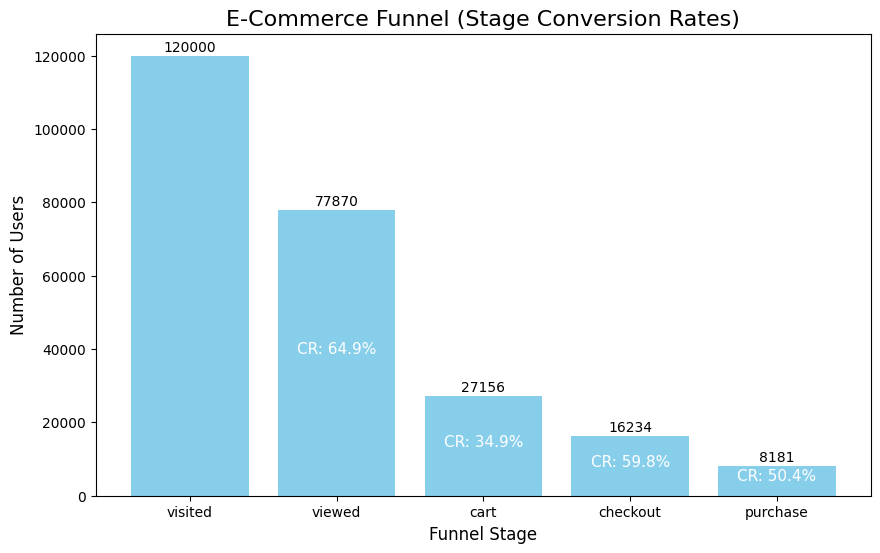

In [20]:
# Prepare funnel stages and user counts
stages = df_funnel_overview_vertical.index.tolist()
users = df_funnel_overview_vertical['Users'].tolist()

# Step-wise conversion rates for overlay (None for first stage)
conversion_rates = [None, 0.649, 0.349, 0.598, 0.504]

# Plot the funnel bar chart
plt.figure(figsize=(10, 6))
plt.bar(stages, users, color='skyblue')
plt.title("E-Commerce Funnel (Stage Conversion Rates)", fontsize=16)
plt.xlabel("Funnel Stage", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)

# Add labels above bars
for i, v in enumerate(users):
    # Display number of users
    plt.text(i, v + max(users)*0.01, str(v), ha='center', fontsize=10)

    # Display conversion rate on the bar
    if conversion_rates[i] is not None:
        plt.text(i, v*0.5, f"CR: {conversion_rates[i]*100:.1f}%",
                 ha='center', color='white', fontsize=11)


plt.show()

### Key Insights

1. **Strong initial engagement**  
Out of 120,000 sessions, 64.9% of users viewed a product after visiting the website, indicating that landing pages and product discovery mechanisms drive effective initial engagement.

2. **Largest drop-off between product view and cart addition**  
Only 34.9% of users who viewed a product added it to the cart. This is the most significant drop-off point, suggesting potential issues such as:
- Insufficient product information  
- Product pricing  
- Lack of trust signals  
- Suboptimal product page UX

3. **Checkout progression is relatively strong**  
Among users who add items to their cart, 59.8% proceed to checkout, reflecting high purchase intent for this group.

4. **Moderate checkout completion rate**  
Approximately 50.4% of users who start checkout complete the purchase. This indicates friction during checkout, such as:
- Complicated checkout forms  
- Payment issues  
- Unexpected shipping costs

---
### Business Recommendations

1. **Improve product page conversion**  
Enhance the largest drop-off stage by implementing:
- Clearer product descriptions  
- Better product images  
- Customer reviews  
- Promotional incentives

2. **Optimize the checkout experience**  
Reduce friction to increase completion rates:
- Simplified checkout forms  
- Multiple payment options  
- Transparent shipping costs

3. **Run A/B tests on product page design**  
Identify design or content changes that increase cart additions and improve overall funnel performance.

## Funnel Segmentation Analysis

The funnel is segmented to analyze performance across marketing sources.  

- **Stage metrics:** For each segment, key funnel stages (visited, viewed, cart, checkout, purchase) are counted.  
- **Step-wise conversion rates:** Ratios between consecutive stages are calculated to highlight drop-offs per segment.  
- **Purpose:** This segmentation helps identify high-performing channels or campaigns and areas needing optimization.

### Funnel Segmentation Analysis by **channel** (SQL)

This section analyzes the funnel by channel.

In [21]:
# Funnel segmentation by channel
query_channel_segmentation = """WITH funnel_segmentation AS (
                                  SELECT
                                      channel,
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel
                                  GROUP BY channel
                                  )

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_segmentation;"""

df_channel_segmentation = pd.read_sql(query_channel_segmentation, conn)
print(df_channel_segmentation)

    channel  total_sessions  visited  viewed   cart  checkout  purchase  \
0     Email           12092    12092    7892   2838      1722       884   
1   Organic           35946    35946   23327   8158      4909      2448   
2  Paid Ads           53891    53891   35011  12058      7161      3619   
3    Social           18071    18071   11640   4102      2442      1230   

   visit_to_view_rate  view_to_cart_rate  cart_to_checkout_rate  \
0               0.653              0.360                  0.607   
1               0.649              0.350                  0.602   
2               0.650              0.344                  0.594   
3               0.644              0.352                  0.595   

   checkout_to_purchase_rate  
0                      0.513  
1                      0.499  
2                      0.505  
3                      0.504  


### Marketing Performance Analysis — Funnel by Channel

This visualization compares funnel stage performance across marketing channels.
User counts are displayed for each funnel stage, while step-wise conversion rates highlight how effectively each channel moves traffic through the funnel.

The chart helps identify channels that generate high engagement, strong purchase intent, or significant drop-offs during the conversion process.


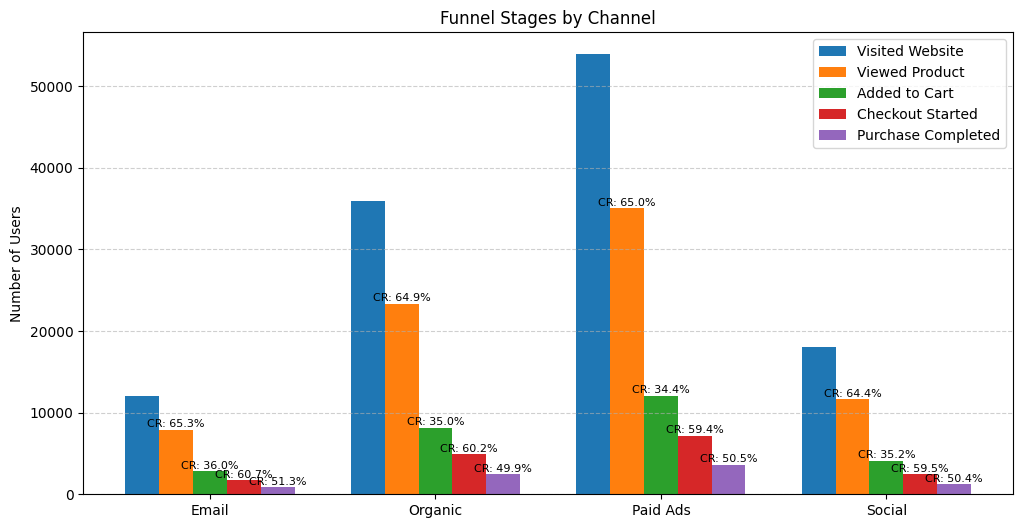

In [22]:
# Funnel stage columns in the dataset
stage_cols = ['visited', 'viewed', 'cart', 'checkout', 'purchase']
# Readable names for funnel stages
stages = [
"Visited Website",
"Viewed Product",
"Added to Cart",
"Checkout Started",
"Purchase Completed"
]

# Extract marketing channels
channels = df_channel_segmentation['channel'].tolist()
# Conversion rate columns between stages
rates = ["visit_to_view_rate", "view_to_cart_rate", "cart_to_checkout_rate", "checkout_to_purchase_rate"]
# Prepare user counts for each funnel stage
funnel_data = [df_channel_segmentation[stage].tolist() for stage in stage_cols]
# Prepare conversion rate data
conversion_rate_data = [df_channel_segmentation[rate].tolist() for rate in rates]

x = np.arange(len(channels))  # base positions for channels on x-axis
width = 0.15                  # width of each bar

# Create chart
plt.figure(figsize=(12,6))

# Plot funnel stages as grouped bars
for i, stage in enumerate(stages):
    plt.bar(x + i*width, funnel_data[i], width=width, label=stage)

    # Add conversion rate labels (from stage 2 onward)
    if i > 0:
        for j in range(len(channels)):
            rate = conversion_rate_data[i-1][j]
            plt.text(
                x[j] + i*width,
                funnel_data[i][j] + 300,
                f"CR: {rate:.1%}",
                ha='center',
                fontsize=8
            )

# Chart styling
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(x + width*2, channels)
plt.ylabel('Number of Users')
plt.title('Funnel Stages by Channel')
plt.legend()
plt.show()


###Channel Performance Insights

**Paid Ads generate the largest traffic volume**

Paid Ads account for the highest number of sessions (~54k visits), significantly exceeding other channels. However, conversion rates across funnel stages are slightly lower compared to other channels (except for the Purchase Completed stage), indicating potential differences in traffic quality.

**Email traffic shows strong conversion efficiency**

Although Email drives the smallest number of sessions (~12k), it demonstrates the strongest conversion performance.

In particular, **View -> Cart conversion (~36%)** and **Cart → Checkout (~60.7%)** are the highest among channels, suggesting highly engaged users.

**Organic channel delivers balanced performance**

Organic search generates a substantial number of sessions (~36k) while maintaining stable conversion rates across the funnel. This indicates users arriving via search often have clear purchase intent.

**Social channel performs moderately**

Social media generates moderate traffic (~18k sessions) with conversion rates comparable to other channels, indicating reasonable engagement but room for optimization.

---

### Business Recommendations

**Scale high-performing channels**

Email and Organic traffic demonstrate strong conversion efficiency, making them valuable channels for sustainable growth.

Potential actions include:

- expanding email marketing campaigns
- improving SEO content strategy
- increasing personalization in email communication

**Improve Paid Ads traffic quality**

Although Paid Ads generate the most traffic, optimizing targeting and message alignment may improve conversion rates.

Potential improvements include:

- refined audience targeting
- improved ad–landing page alignment
- better campaign segmentation

**Optimize product page conversion**

The largest drop-off occurs between **Product View → Cart Addition** across all channels.
Improving product page experience could significantly increase overall funnel performance.


### Funnel Segmentation Analysis by **campaign type**

This section analyzes the funnel by campaign type.

In [23]:
# Funnel segmentation by campaign type
query_campaign_type_segmentation = """WITH funnel_segmentation AS (
                                  SELECT
                                      campaign_type,
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel
                                  GROUP BY campaign_type
                                  )

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_segmentation;"""

df_campaign_type_segmentation = pd.read_sql(query_campaign_type_segmentation, conn)
print(df_campaign_type_segmentation)

  campaign_type  total_sessions  visited  viewed   cart  checkout  purchase  \
0      Discount           60121    60121   38950  13541      8087      4107   
1    Influencer           23815    23815   15423   5465      3240      1626   
2    New Launch           36064    36064   23497   8150      4907      2448   

   visit_to_view_rate  view_to_cart_rate  cart_to_checkout_rate  \
0               0.648              0.348                  0.597   
1               0.648              0.354                  0.593   
2               0.652              0.347                  0.602   

   checkout_to_purchase_rate  
0                      0.508  
1                      0.502  
2                      0.499  


### Marketing Performance Analysis — Funnel by Campaign Type

This visualization compares funnel stage performance across different campaign types.

User counts are displayed for each funnel stage, while step-wise conversion rates are shown on the bars to highlight how efficiently each campaign type moves users through the funnel.

The analysis helps identify which campaign strategies generate high engagement, strong purchase intent, or significant drop-offs during the conversion process.

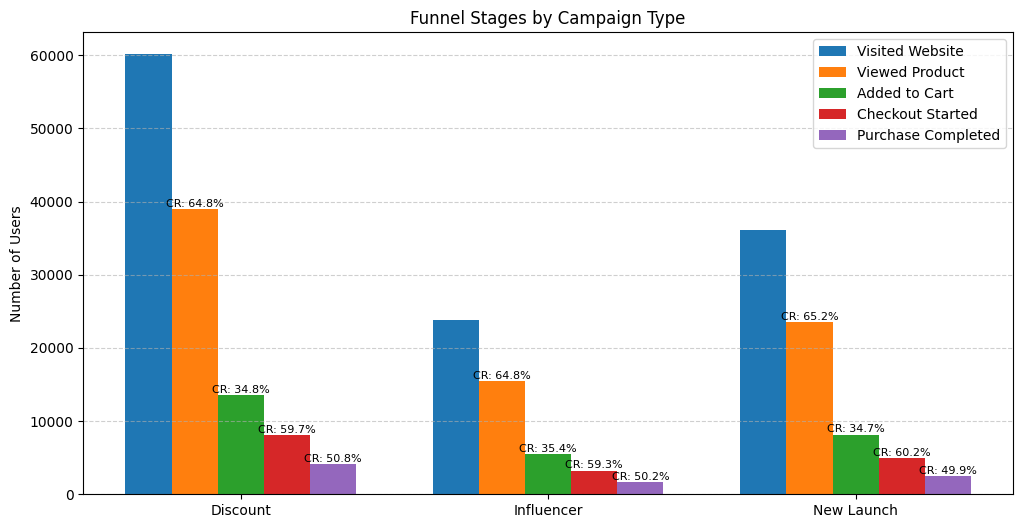

In [24]:
# Funnel stage columns
stage_cols = ['visited', 'viewed', 'cart', 'checkout', 'purchase']
# Readable funnel stage names
stages = [
"Visited Website",
"Viewed Product",
"Added to Cart",
"Checkout Started",
"Purchase Completed"
]
# Extract campaign types
campaign_type = df_campaign_type_segmentation['campaign_type'].tolist()
# Conversion rate columns between funnel stages
rates = ["visit_to_view_rate", "view_to_cart_rate", "cart_to_checkout_rate", "checkout_to_purchase_rate"]
# Prepare user counts for each funnel stage
funnel_data = [df_campaign_type_segmentation[stage].tolist() for stage in stage_cols]
# Prepare conversion rate values
conversion_rate_data = [df_campaign_type_segmentation[rate].tolist() for rate in rates]

x = np.arange(len(campaign_type))  # base positions for campaign types on x-axis
width = 0.15                  # width of each bar

# Create chart
plt.figure(figsize=(12,6))

# Plot grouped bars for each funnel stage
for i, stage in enumerate(stages):
    plt.bar(x + i*width, funnel_data[i], width=width, label=stage)

    # Add conversion rate labels starting from stage 2
    if i > 0:
        for j in range(len(campaign_type)):
            rate = conversion_rate_data[i-1][j]
            plt.text(
                x[j] + i*width,
                funnel_data[i][j] + 300,
                f"CR: {rate:.1%}",
                ha='center',
                fontsize=8
            )

# Chart styling
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(x + width*2, campaign_type)
plt.ylabel('Number of Users')
plt.title('Funnel Stages by Campaign Type')
plt.legend()
plt.show()

###Key Insights
**Discount campaigns drive the highest traffic**

The Discount campaign generates the largest number of sessions, indicating that promotional offers are effective at attracting users to the website.

However, conversion behavior across the funnel remains similar to other campaign types, suggesting that discounts mainly impact traffic acquisition rather than funnel efficiency.

**Influencer campaigns show slightly stronger product interest**

The Influencer campaign has the highest View → Cart conversion (~35.4%), which suggests that users coming from influencer promotions may have stronger product interest or trust.

This indicates that influencer marketing may help improve product discovery and engagement.

**New product launch campaigns maintain stable funnel performance**

The New Launch campaign shows consistent conversion rates across funnel stages, including one of the stronger Cart → Checkout conversion rates (~60.2%).

This suggests that new product announcements can successfully generate both interest and purchase intent.

**Funnel behavior is consistent across campaign types**

Despite differences in traffic volume, conversion rates across campaign types are relatively similar, which indicates that the main funnel friction points are likely related to the website experience rather than the marketing channel.

In particular, the largest drop-off still occurs between product view and cart addition, consistent with the overall funnel analysis.

---

### Business Recommendations

**Continue leveraging discount campaigns for traffic acquisition**

Discount promotions appear to be effective at generating large traffic volumes and should remain an important part of the marketing strategy.

**Expand influencer collaborations**

Since influencer campaigns show slightly stronger engagement in the View → Cart stage, expanding partnerships with influencers could increase product interest and brand trust.

**Optimize product page experience**

Because the largest drop-off consistently occurs between product view and cart addition across all campaign types, improving product page design could significantly increase conversion performance for all marketing campaigns.

##Revenue Opportunity Analysis

###Stage-wise Lost Users Calculation

This analysis calculates the number of users lost at each step of the funnel.  
It helps identify which stage has the largest drop-off and therefore needs optimization.

**Calculation details:**  
- `lost_visited_to_view` = Users who visited the website but did not view a product  
- `lost_viewed_to_cart` = Users who viewed a product but did not add to cart  
- `lost_cart_to_checkout` = Users who added to cart but did not start checkout  
- `lost_checkout_to_purchase` = Users who started checkout but did not complete purchase  
- `avg_order_value` = Average order value across all purchases

In [25]:
# Stage-wise Lost Users Calculation
# Calculates users lost at each funnel step and average order value
query_stage_wise_lost_users = """WITH funnel_segmentation AS (
                                        SELECT
                                            SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                            SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                            SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                            SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                            SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase,
                                            ROUND(AVG(order_value), 2) AS avg_order_value
                                  FROM marketing_funnel)
                                        SELECT *,
                                            visited - viewed AS lost_visited_to_view,
                                            viewed - cart AS lost_viewed_to_cart,
                                            cart - checkout AS lost_cart_to_checkout,
                                            checkout - purchase AS lost_checkout_to_purchase
                                        FROM funnel_segmentation;"""
df_stage_wise_lost_users = pd.read_sql(query_stage_wise_lost_users, conn)
df_stage_wise_lost_users

,visited,viewed,cart,checkout,purchase,avg_order_value,lost_visited_to_view,lost_viewed_to_cart,lost_cart_to_checkout,lost_checkout_to_purchase
0,120000,77870,27156,16234,8181,614.96,42130,50714,10922,8053


### Stage-wise Lost Revenue Calculation & Visualisation

This analysis estimates the **revenue lost** at each funnel stage by multiplying lost users by the average order value.  
It helps highlight which stage drop-offs cost the most revenue.

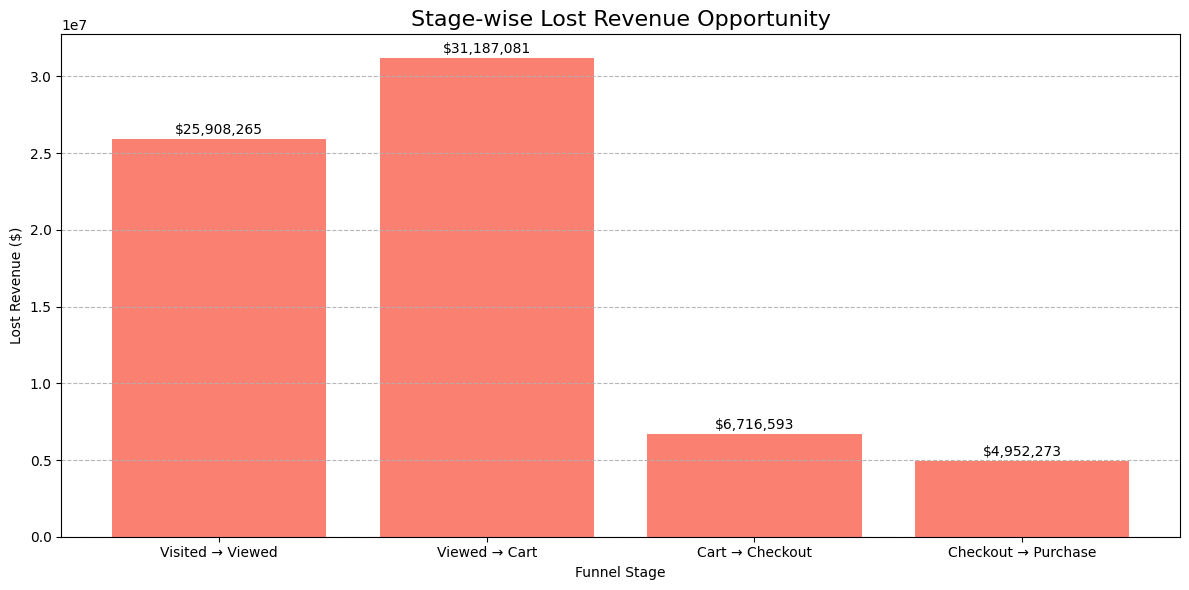

In [26]:
# Extract lost users at each funnel stage
lost_users = df_stage_wise_lost_users.loc[0, [
                      'lost_visited_to_view',
                      'lost_viewed_to_cart',
                      'lost_cart_to_checkout',
                      'lost_checkout_to_purchase'
]].tolist()
# Get the average order value
avg_order_value = df_stage_wise_lost_users.loc[0, 'avg_order_value']
# Calculate lost revenue per stage
lost_revenue = [lost_user*avg_order_value for lost_user in lost_users]
# Funnel stage labels
stages = ['Visited → Viewed', 'Viewed → Cart', 'Cart → Checkout', 'Checkout → Purchase']

# Plot the lost revenue as a bar chart
plt.figure(figsize=(12, 6))
plt.bar(stages, lost_revenue, color='salmon')
plt.title("Stage-wise Lost Revenue Opportunity", fontsize=16)
plt.xlabel("Funnel Stage")
plt.ylabel("Lost Revenue ($)")
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.tight_layout()

# Add revenue value labels on top of each bar
for i, revenue in enumerate(lost_revenue):
    plt.text(i, revenue + max(lost_revenue)*0.01, f"${revenue:,.0f}", ha='center')

plt.show()

###Revenue Opportunity Insight

The largest revenue loss occurs between the Viewed Product → Added to Cart stage, representing approximately $31M in potential lost revenue.

This suggests that improving product page conversion (better product descriptions, reviews, pricing transparency, or promotional incentives) could unlock significant revenue growth

##Limitations

While the analysis provides useful insights, several limitations should be considered.

The dataset represents session-level behavior rather than full user journeys across multiple sessions, meaning that repeat visits by the same user cannot be fully tracked.

The analysis also focuses primarily on funnel stage transitions, without deeper behavioral signals such as time on page, product category interest, or browsing depth.

Additionally, the lost revenue estimates are based on the average order value, which assumes that users who dropped off would have converted at similar order values. In reality, not all lost users would complete a purchase.

Finally, marketing attribution is simplified, as each session is associated with only a single channel and campaign type.

These limitations mean that the findings should be interpreted as high-level behavioral patterns and revenue opportunities, rather than precise causal relationships.

##Future Work

Future analysis could extend this project in several directions.

A deeper analysis of conversion rates by marketing channel and campaign type could help identify which acquisition strategies drive not only traffic, but also high-quality conversions.

Further investigation into device-specific behavior could reveal whether mobile users experience higher friction during the product page or checkout stages.

A cohort analysis comparing new and returning users would provide better insight into long-term customer behavior and retention patterns.

Finally, the insights from this project could be validated through A/B testing experiments, particularly focusing on product page design and checkout optimization to reduce the largest funnel drop-off points.

## Appendix – Additional Exploratory Queries

These queries are available for further exploration but have not yet been used in the main analysis:

- Breakdown by **user type** (e.g., new vs returning users)  
- Breakdown by **device type** (desktop, mobile)  
- Breakdown by **region** (Metro, Non-Metro)  
- Breakdown by **month** or time period  
- Breakdown by key double columns
- Breakdown by key triple columns

> Note: These exploratory queries can help uncover additional patterns, trends, or anomalies in user behavior beyond the main funnel segmentation.

### Segmentation based on user type

In [27]:
# Query to calculate funnel metrics grouped by user type
query_user_type_segmentation = """WITH funnel_segmentation AS (
                                  SELECT
                                      user_type,
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel
                                  GROUP BY user_type
                                  )

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_segmentation;"""

df_user_type_segmentation = pd.read_sql(query_user_type_segmentation, conn)
print(df_user_type_segmentation)

   user_type  total_sessions  visited  viewed   cart  checkout  purchase  \
0        New           77969    77969   50616  17730     10658      5398   
1  Returning           42031    42031   27254   9426      5576      2783   

   visit_to_view_rate  view_to_cart_rate  cart_to_checkout_rate  \
0               0.649              0.350                  0.601   
1               0.648              0.346                  0.592   

   checkout_to_purchase_rate  
0                      0.506  
1                      0.499  


### Segmentation based on device

In [28]:
# Query to calculate funnel metrics grouped by device type
query_device_segmentation = """WITH funnel_segmentation AS (
                                  SELECT
                                      device,
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel
                                  GROUP BY device
                                  )

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_segmentation;"""

df_device_segmentation = pd.read_sql(query_device_segmentation, conn)
print(df_device_segmentation)

    device  total_sessions  visited  viewed   cart  checkout  purchase  \
0  Desktop           35994    35994   23373   8140      4893      2488   
1   Mobile           84006    84006   54497  19016     11341      5693   

   visit_to_view_rate  view_to_cart_rate  cart_to_checkout_rate  \
0               0.649              0.348                  0.601   
1               0.649              0.349                  0.596   

   checkout_to_purchase_rate  
0                      0.508  
1                      0.502  


### Segmentation based on region

In [29]:
# Query to calculate funnel metrics grouped by region
query_region_segmentation = """WITH funnel_segmentation AS (
                                  SELECT
                                      region,
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel
                                  GROUP BY region
                                  )

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_segmentation;"""

df_region_segmentation = pd.read_sql(query_region_segmentation, conn)
print(df_region_segmentation)

      region  total_sessions  visited  viewed   cart  checkout  purchase  \
0      Metro           72014    72014   46651  16181      9643      4909   
1  Non-Metro           47986    47986   31219  10975      6591      3272   

   visit_to_view_rate  view_to_cart_rate  cart_to_checkout_rate  \
0               0.648              0.347                  0.596   
1               0.651              0.352                  0.601   

   checkout_to_purchase_rate  
0                      0.509  
1                      0.496  


### Segmentation based on month

In [30]:
# Query to calculate funnel metrics grouped by month
query_month_segmentation = """WITH funnel_segmentation AS (
                                  SELECT
                                      month,
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel
                                  GROUP BY month
                                  )

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_segmentation;"""

df_month_segmentation = pd.read_sql(query_month_segmentation, conn)
print(df_month_segmentation)

     month  total_sessions  visited  viewed  cart  checkout  purchase  \
0  2025-07           20747    20747   13431  4645      2822      1437   
1  2025-08           20489    20489   13298  4630      2749      1372   
2  2025-09           20167    20167   13162  4601      2800      1424   
3  2025-10           20625    20625   13404  4712      2779      1401   
4  2025-11           19914    19914   12843  4547      2677      1316   
5  2025-12           18058    18058   11732  4021      2407      1231   

   visit_to_view_rate  view_to_cart_rate  cart_to_checkout_rate  \
0               0.647              0.346                  0.608   
1               0.649              0.348                  0.594   
2               0.653              0.350                  0.609   
3               0.650              0.352                  0.590   
4               0.645              0.354                  0.589   
5               0.650              0.343                  0.599   

   checkout_to_pur

### Key Double Segmentations

In [31]:
# Query to calculate funnel metrics grouped by channel and user type
query_channel_user_type_segmentation = """WITH funnel_segmentation AS (
                                  SELECT
                                      channel,
                                      user_type,
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel
                                  GROUP BY channel, user_type
                                  )

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_segmentation;"""

df_channel_user_type_segmentation = pd.read_sql(query_channel_user_type_segmentation, conn)
print(df_channel_user_type_segmentation)

# Query to calculate funnel metrics grouped by campaign type and device
query_campaign_type_device_segmentation = """WITH funnel_segmentation AS (
                                  SELECT
                                      campaign_type,
                                      device,
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel
                                  GROUP BY campaign_type, device
                                  )

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_segmentation;"""

df_campaign_type_device_segmentation = pd.read_sql(query_campaign_type_device_segmentation, conn)
print(df_campaign_type_device_segmentation)

# Query to calculate funnel metrics grouped by channel and device
query_channel_device_segmentation = """WITH funnel_segmentation AS (
                                  SELECT
                                      channel,
                                      device,
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel
                                  GROUP BY channel, device
                                  )

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_segmentation;"""

df_channel_device_segmentation = pd.read_sql(query_channel_device_segmentation, conn)
print(df_channel_device_segmentation)

# Query to calculate funnel metrics grouped by region and user type
query_region_user_type_segmentation = """WITH funnel_segmentation AS (
                                  SELECT
                                      region,
                                      user_type,
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel
                                  GROUP BY region, user_type
                                  )

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_segmentation;"""

df_region_user_type_segmentation = pd.read_sql(query_region_user_type_segmentation, conn)
print(df_region_user_type_segmentation)

    channel  user_type  total_sessions  visited  viewed  cart  checkout  \
0     Email        New            7917     7917    5207  1896      1158   
1     Email  Returning            4175     4175    2685   942       564   
2   Organic        New           23440    23440   15255  5352      3203   
3   Organic  Returning           12506    12506    8072  2806      1706   
4  Paid Ads        New           34887    34887   22595  7828      4688   
5  Paid Ads  Returning           19004    19004   12416  4230      2473   
6    Social        New           11725    11725    7559  2654      1609   
7    Social  Returning            6346     6346    4081  1448       833   

   purchase  visit_to_view_rate  view_to_cart_rate  cart_to_checkout_rate  \
0       602               0.658              0.364                  0.611   
1       282               0.643              0.351                  0.599   
2      1592               0.651              0.351                  0.598   
3       856     

### Key Triple Segmentaion

In [32]:
# Query to calculate funnel metrics grouped by region, month and user type
query_region_month_user_type_segmentation = """WITH funnel_segmentation AS (
                                  SELECT
                                      region,
                                      month,
                                      user_type,
                                      COUNT(*) AS total_sessions,
                                      SUM(CASE WHEN visited_website = 'Yes' THEN 1 END) AS visited,
                                      SUM(CASE WHEN viewed_product = 'Yes' THEN 1 END) AS viewed,
                                      SUM(CASE WHEN added_to_cart = 'Yes' THEN 1 END) AS cart,
                                      SUM(CASE WHEN checkout_started = 'Yes' THEN 1 END) AS checkout,
                                      SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 END) AS purchase
                                  FROM marketing_funnel
                                  GROUP BY region, month, user_type
                                  )

                                  SELECT *,
                                        ROUND(1.0 * viewed/NULLIF(visited, 0), 3) AS visit_to_view_rate,
                                        ROUND(1.0 * cart/NULLIF(viewed, 0), 3) AS view_to_cart_rate,
                                        ROUND(1.0 * checkout/NULLIF(cart, 0), 3) AS cart_to_checkout_rate,
                                        ROUND(1.0 * purchase/NULLIF(checkout, 0), 3) AS checkout_to_purchase_rate
                                  FROM funnel_segmentation;"""

df_region_month_user_type_segmentation = pd.read_sql(query_region_month_user_type_segmentation, conn)
print(df_region_month_user_type_segmentation)

       region    month  user_type  total_sessions  visited  viewed  cart  \
0       Metro  2025-07        New            8118     8118    5231  1824   
1       Metro  2025-07  Returning            4374     4374    2850   991   
2       Metro  2025-08        New            8036     8036    5182  1775   
3       Metro  2025-08  Returning            4320     4320    2832   986   
4       Metro  2025-09        New            7854     7854    5097  1764   
5       Metro  2025-09  Returning            4208     4208    2741   962   
6       Metro  2025-10        New            8083     8083    5254  1859   
7       Metro  2025-10  Returning            4368     4368    2867  1013   
8       Metro  2025-11        New            7722     7722    5013  1733   
9       Metro  2025-11  Returning            4247     4247    2721   967   
10      Metro  2025-12        New            6915     6915    4422  1499   
11      Metro  2025-12  Returning            3769     3769    2441   808   
12  Non-Metr